# Correlation of instances with signer counts

| EXP NO    | Model    | Metric     | Split         | 
|-----------|----------|------------|---------------|
| 000       | MViTv2_S | F1-score   | WLASL-2000    |

Independant variables on the `train` set (per class):
- Number of instances 
- Number of unique signers


Using the preprocessed split where videos with <= 9 frames were removed:
|Split      |  Video id             |
|-----------|-----------------------|
| asl1000   | 18223, 59958          |
| asl2000   | 18223, 59958, 15144   |

If frame start or frame end were labeled wrong, they were set to 0 or frame length

In [49]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import src.preprocess as preproc
from src.configs import get_class_list
from src.run_types import AVAIL_SETS, CUTOFF_9_NAMES, CUTOFF_SPLITS, RESULTS_OUTPUTS
from src.stats import (
    create_instances_table,
    get_min_max_num_instances,
    get_min_max_num_signers,
)
from src.video_dataset import get_wlasl_info
from src.visualise2 import (
    DEFAULT_ACCENT,
    LINE_PALETTE,
    plot_metric_correlation,
    save_fig,
    set_thesis_style,
)

verbosity = 1
def printv(*args, level=1, **kwargs):
    if level <= verbosity:
        print(*args, **kwargs)

## Set params

In [50]:



# split_options: list[AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000"]
split_options: list[CUTOFF_SPLITS] = CUTOFF_9_NAMES
set_options: list[AVAIL_SETS] = ['train', 'test', 'val']
split_name : CUTOFF_SPLITS = 'asl2000_cutoff_9'
set_name : AVAIL_SETS = 'train'
metric = 'num_instances'
classes = get_class_list()
set_thesis_style()

project_name = 'satnac_2026'
output_dir = RESULTS_OUTPUTS / project_name

print(f'Split: {split_name} Set: {set_name}')

Split: asl2000_cutoff_9 Set: train


## Load stats

Dataset information:

In [51]:
dataset_info = get_wlasl_info(split_name, set_name)
print(json.dumps({k : str(v) for k, v in dataset_info.items()}, indent=4))

{
    "root": "/home/luke/Code/SLR/data/WLASL/WLASL2000",
    "labels": "/home/luke/Code/SLR/data/WLASL/preprocessed/labels/asl2000_cutoff_9",
    "label_suff": "fixed_frange_bboxes.json",
    "set_name": "train"
}


### Show variation of datasets in a table

In [52]:
from src.stats import (
    WLASLClass,
    get_set_stats,
    retrieve_split_data,
    reverse_preproc_format,
)

all_splits = {split : {} for split in split_options}

set_name : AVAIL_SETS = 'train'
for split_name in split_options:
    # split_dir = labels_dir / split_name
    dataset_info = get_wlasl_info(split_name, set_name)
    split_dir = dataset_info['labels']
    labels_dir = dataset_info['labels'].parent
    label_suffix = dataset_info['label_suff']
    set_info = retrieve_split_data(split=split_name, labels_dir=labels_dir, pattern=f'*{label_suffix}')
    seperated = {}
    set_keys = ['train', 'test', 'val']
    print(f'Split info for {split_name}')
    for  key, value in set_info.items():
        preproc_set = [preproc.Instance.model_validate(v) for v in value]
        
        for set_key in set_keys:
            if key.startswith(set_key):
                seperated[set_key] = preproc_set
                break
    
    sep_wlasl_order = {}
    for key, value in seperated.items():
        sep_wlasl_order[key] = reverse_preproc_format(value, classes=classes)

    
    per_set_stats = {}
    for set_name, glosses_subset in sep_wlasl_order.items():
        per_set_stats[set_name] = get_set_stats([WLASLClass.model_validate(g) for g in glosses_subset])

    all_splits[split_name] = per_set_stats
    
    display(create_instances_table(per_set_stats))
    print('\n', '-'*10)

Split info for asl100_cutoff_9


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,338,69,[3 - 6],[2 - 6]
1,test,258,56,[2 - 5],[2 - 4]
2,train,1442,91,[12 - 30],[7 - 15]



 ----------
Split info for asl300_cutoff_9


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,901,88,[2 - 6],[2 - 6]
1,test,668,74,[2 - 5],[1 - 4]
2,train,3549,104,[9 - 30],[5 - 15]



 ----------
Split info for asl1000_cutoff_9


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,2319,101,[1 - 6],[1 - 6]
1,test,1876,89,[1 - 5],[1 - 4]
2,train,8977,113,[6 - 30],[4 - 15]



 ----------
Split info for asl2000_cutoff_9


,Set name,Num instances,Num signers,instances per gloss,signers per gloss
0,val,3917,109,[1 - 6],[1 - 6]
1,test,2879,105,[1 - 5],[1 - 4]
2,train,14290,117,[1 - 30],[1 - 15]



 ----------


## Fetch results and create dataframes

In [53]:
from typing import cast

num_classes = 2000
per_set_stats = all_splits[split_name]
exp_no = 'exp000'
model_name = 'MViTv2_S' # can also use MViTv2_S_e and S3D
checkpoint_num = None # override if multitple runs of the same experiment
split_name : CUTOFF_SPLITS = 'asl2000_cutoff_9'

### Fetch results

#### Set paths for stashing pre run runs

In [54]:
# write files for easy access when finished
res_out_dir = Path("./outputs/")
res_out_dir.mkdir(parents=True, exist_ok=True)

stub = f"{split_name}_{model_name}_{exp_no}_{str(checkpoint_num) + '_' if checkpoint_num is not None else ''}"
out = f"{stub}results.json"

#### Run tests if not already done and stash results

In [55]:
def run_tests():
    from src.testing import (
        DATA_FNAME,
        MinInfo,
        get_model_checkpoint_dir,
        get_model_exp_dir,
        load_test_sizes,
        test_run,
    )

    # Load model and data + evaluate
    output = get_model_exp_dir(split=split_name, model=model_name, exp_no=int(exp_no))
    save_path = get_model_checkpoint_dir(output, checkpoint_num)
    admin = MinInfo(model=model_name, split=split_name, save_path=str(save_path))
    
    data_info_path = output / DATA_FNAME
    print(f"Loaded data info from {data_info_path}")
    data = load_test_sizes(output)
    

    results, cls_report, all_targets, all_preds = test_run(
        admin=admin, data=data, set_name="test", shuffle=False, save=False
    )

    all_results = {
        "cls_report": cls_report,
        "base_res": results.model_dump(),
        "all_targets": [int(i) for i in all_targets],
        "all_preds": [int(i) for i in all_preds],
    }


    with open(res_out_dir / out, 'w') as f:
        json.dump(all_results, f)

    
    print(f'Saved to: {out}')
    
    return all_results

# all_results =  run_tests()


#### Stash results from previous runs for easy access

With either of these commented out blocks from `MViTv2_S_e` `exp000`, and `MViTv2_S` `exp002` the correlation of instances count and signer count drop. Overrides the previously inferred testing path.

In [ ]:
def stash_from_saved(original_save_path: Path) -> str:

    results_dir = original_save_path.parent

    exp_dir = results_dir.parent
    model_dir = exp_dir.parent
    split_dir = model_dir.parent
    new_fname = (
        f"{split_dir.name}_{model_dir.name}_{exp_dir.name}_results.json"
    )

    with open(original_save_path, "r") as f:
        cls_rep_all_targets_all_preds = json.load(f)

    with open(res_out_dir / new_fname, "w") as f:
        json.dump(cls_rep_all_targets_all_preds, f)

    return new_fname


# out = stash_from_saved(
#     Path().home()
#     / "Code/SLR/src/runs/asl2000_cutoff_9/MViTv2_S_e/exp000/results/cls_rep_all_targets_preds.json"
# )

# out = stash_from_saved(
#     Path().home()
#     / "Code/SLR/src/runs/asl2000_cutoff_9/MViTv2_S/exp002/results/cls_rep_all_targets_preds.json"
# )



#### Load stashed results



In [66]:
with open(res_out_dir / out, 'r') as f:
    all_results = {k : v for k, v in json.load(f).items()}
    print(all_results.keys())

dict_keys(['cls_report', 'all_targets', 'all_preds'])


### Create F1 Dataframe

In [67]:
cls_rep = all_results["cls_report"]
all_targets = all_results["all_targets"]
all_preds = all_results["all_preds"]

exclude_keys = {"accuracy", "macro avg", "weighted avg"}

per_class_rows = []
for key, metrics_dict in cls_rep.items():
    if key in exclude_keys:
        continue
    # cls_rep keys are either stringified numeric labels (map via classes list)
    # or already gloss strings -- handle both
    if key.isdigit():
        gloss = classes[int(key)]
    else:
        gloss = key
    per_class_rows.append({"gloss": gloss, "f1": metrics_dict["f1-score"]})

f1_df = pd.DataFrame(per_class_rows)
printv(f"Loaded F1 scores for {len(f1_df)} classes")
f1_df.head()

Loaded F1 scores for 2000 classes


,gloss,f1
0,book,0.600000
1,drink,0.666667
2,computer,0.750000
3,before,0.000000
4,chair,0.666667


### Create instance and signer count  Dataframe

In [68]:
train_stats = per_set_stats['train']

stats_rows = []
for gloss, stat in train_stats['per_instance_stats'].items():
    num_instances = stat["num_instances"]
    signers_distribution = stat["signers_distribution"]  # {signer_id: occurrence_count}
    num_signers = len(signers_distribution)  # unique signer count
    stats_rows.append({"gloss": gloss, "num_instances": num_instances, "num_signers": num_signers})

stats_df = pd.DataFrame(stats_rows)
printv(f"Loaded stats for {len(stats_df)} classes")
stats_df.head()

Loaded stats for 2000 classes


,gloss,num_instances,num_signers
0,book,30,14
1,drink,25,15
2,computer,20,12
3,before,18,13
4,chair,19,11


### Create merged dataframe

In [69]:
merged = f1_df.merge(stats_df, on="gloss", how="inner")

if len(merged) != len(f1_df):
    missing = set(f1_df["gloss"]) - set(merged["gloss"])
    print(f"WARNING: {len(missing)} glosses from results not found in training stats: {missing}")

merged.head()

,gloss,f1,num_instances,num_signers
0,book,0.600000,30,14
1,drink,0.666667,25,15
2,computer,0.750000,20,12
3,before,0.000000,18,13
4,chair,0.666667,19,11


## F1 vs. instance count

number of examples

Saved to /home/luke/Code/SLR/src/results/outputs/satnac_2026/corr_mat_asl2000_cutoff_9_MViTv2_S_exp002_results.json.pdf
Instance count correlation: tau=0.188, p=3.441e-25


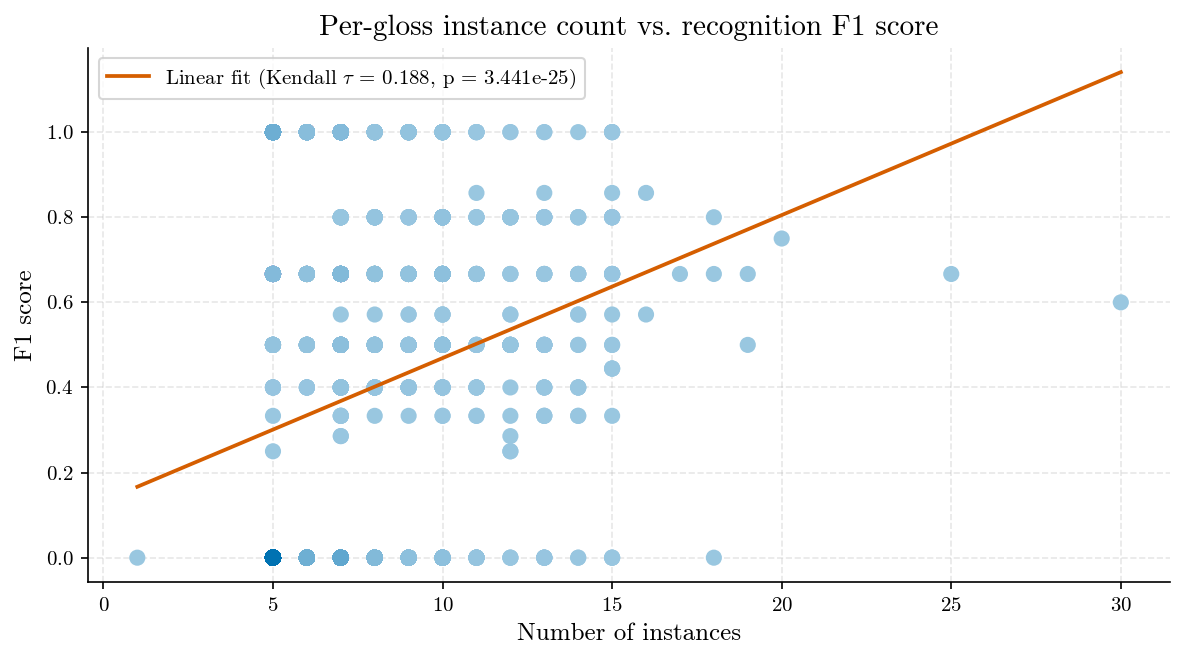

In [70]:
instance_plot_path = output_dir / f"corr_mat_{out}.pdf"
fig1, ax1, tau_inst, p_inst = plot_metric_correlation(
    merged["num_instances"],
    merged["f1"],
    title="Per-gloss instance count vs. recognition F1 score",
    xlabel="Number of instances",
)
save_fig(fig1, instance_plot_path)
printv(f"Saved to {instance_plot_path}")
print(f"Instance count correlation: tau={tau_inst:.3f}, p={p_inst:.3e}")

## F1 vs. signer count

number of unique signer ids.

Saved to /home/luke/Code/SLR/src/results/outputs/satnac_2026/corr_signers_asl2000_cutoff_9_MViTv2_S_exp002_results.json.pdf
Signer count correlation: tau=0.201, p=5.020e-29


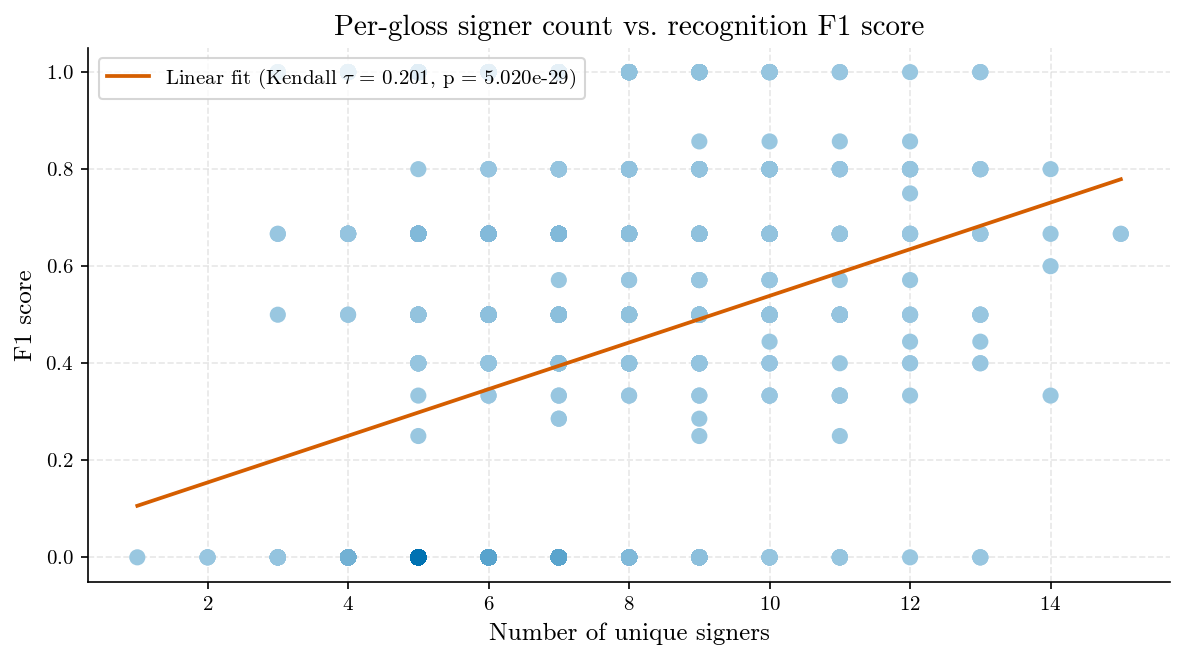

In [71]:
signers_plot_path = output_dir / f"corr_signers_{out}.pdf"
fig2, ax2, tau_signers, p_signers = plot_metric_correlation(
    merged["num_signers"],
    merged["f1"],
    title="Per-gloss signer count vs. recognition F1 score",
    xlabel="Number of unique signers",
)
save_fig(fig2, signers_plot_path)
printv(f"Saved to {signers_plot_path}")
print(f"Signer count correlation: tau={tau_signers:.3f}, p={p_signers:.3e}")

## Collect performance outliers

In [63]:
def get_performance_outliers(
    set_statistics: dict,
    cls_report: dict[str, dict[str, float]],
    class_to_idx: dict[str, int],
    low_signer_thresh: int = 3,
    high_f1_thresh: float = 0.80,
    high_signer_thresh: int = 10,
    low_f1_thresh: float = 0.20
):
    """Extracts and prints overachieving and underachieving glosses."""
    
    data = []
    
    # 1. Compile all data into a single list of dictionaries
    for gloss, instance in set_statistics['per_instance_stats'].items():
        idx = class_to_idx.get(gloss)
        if idx is None:
            continue
            
        report_entry = cls_report.get(str(idx))
        if report_entry is None:
            continue
            
        num_instances = instance['num_instances']
        num_signers = len(instance['signers_distribution'])
        f1_score = report_entry["f1-score"]
        
        data.append({
            "Gloss": gloss,
            "Instances": num_instances,
            "Signers": num_signers,
            "F1_Score": f1_score
        })
        
    df = pd.DataFrame(data)
    
    # 2. Filter for Overachievers (Low data, High F1)
    overachievers = df[
        (df['Signers'] <= low_signer_thresh) & 
        (df['F1_Score'] >= high_f1_thresh)
    ].sort_values(by=['F1_Score', 'Signers'], ascending=[False, True])
    
    # 3. Filter for Underachievers (High data, Low F1)
    underachievers = df[
        (df['Signers'] >= high_signer_thresh) & 
        (df['F1_Score'] <= low_f1_thresh)
    ].sort_values(by=['F1_Score', 'Signers'], ascending=[True, False])
    
    # 4. Print the results nicely
    print("🏆 THE OVERACHIEVERS 🏆")
    print(f"Glosses with <= {low_signer_thresh} signers but F1 >= {high_f1_thresh}")
    print("-" * 50)
    if overachievers.empty:
        print("No glosses met this criteria. (You may need to adjust the thresholds).")
    else:
        print(overachievers.to_string(index=False))
        
    print("\n\n" + "="*50 + "\n")
    
    print("📉 THE UNDERACHIEVERS 📉")
    print(f"Glosses with >= {high_signer_thresh} signers but F1 <= {low_f1_thresh}")
    print("-" * 50)
    if underachievers.empty:
        print("No glosses met this criteria. (You may need to adjust the thresholds).")
    else:
        print(underachievers.to_string(index=False))

    return overachievers, underachievers

# --- How to call the function ---
# Pass the 'train' split stats to see what it learned from!
over_df, under_df = get_performance_outliers(
    set_statistics=per_set_stats['train'], 
    cls_report=cls_rep, 
    class_to_idx={k : i for i, k in enumerate(classes)},
    # You can tweak these thresholds if your lists are too long or too short:
    low_signer_thresh=3,   
    high_f1_thresh=0.80,   
    high_signer_thresh=6, 
    low_f1_thresh=0.20     
)

🏆 THE OVERACHIEVERS 🏆
Glosses with <= 3 signers but F1 >= 0.8
--------------------------------------------------
    Gloss  Instances  Signers  F1_Score
beginning          5        3       1.0
come here          5        3       1.0
 swimsuit          5        3       1.0
wash face          5        3       1.0



📉 THE UNDERACHIEVERS 📉
Glosses with >= 6 signers but F1 <= 0.2
--------------------------------------------------
         Gloss  Instances  Signers  F1_Score
        before         18       13       0.0
          thin         15       13       0.0
           eat         14       13       0.0
        yellow         13       13       0.0
          what         14       12       0.0
          blue         15       12       0.0
          time         14       12       0.0
         wrong         15       11       0.0
          corn         13       11       0.0
         short         13       11       0.0
          need         13       11       0.0
     different         12     

### Save performance outliers file

In [64]:
# 1. Convert the DataFrames into lists of dictionaries
outliers_dict = {
    "overachievers": over_df.to_dict(orient="records"),
    "underachievers": under_df.to_dict(orient="records")
}

# 2. Save the dictionary to a JSON file
fname = "performance_outliers.json"
with open(res_out_dir / fname, "w") as f:
    json.dump(outliers_dict, f, indent=4)

print(f"Successfully saved outliers to {res_out_dir / fname}")

Successfully saved outliers to outputs/performance_outliers.json
